本程序的步骤包括：
# 使用SKLearn的神经网络（NN）进行回归
* 数据理解
* 数据可视化
* 数据准备：
  1. 对所有分类特征进行独热编码
  2. 对所有数值特征进行标准化或归一化
* 使用SKLearn的MLPRegressor（多层感知器）/使用SKLearn的神经网络（NN）进行回归
* 预测
* 评估结果
* 最终成果

# 使用Keras作为后端进行训练
* 数据理解
* 数据可视化
* 数据准备：
  1. 对所有分类特征进行独热编码
  2. 对所有数值特征进行标准化或归一化
* 使用Keras API作为后端进行训练
* 预测
* 评估结果
* 最终成果

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

In [2]:
#示例
#转换为 log1p(count)
#使用 expm1 转回原始计数
print('Test log and exp')
test_count = 100
print('original value', test_count)
x = np.log1p(test_count) # log (x+1)
print('log1p', x)
print('expm1', np.expm1(x)) # exp(x) - 1

Test log and exp
original value 100
log1p 4.61512051684126
expm1 100.00000000000003


In [3]:
columns = ['count', 'season', 'holiday', 'workingday', 'weather', 'temp',
       'atemp', 'humidity', 'windspeed', 'year', 'month', 'day', 'dayofweek','hour']

In [4]:
#加载数据集
df = pd.read_csv('/kaggle/input/bike-sharing-demand/train.csv', parse_dates=['datetime'],index_col=0)
df_test = pd.read_csv('/kaggle/input/bike-sharing-demand/test.csv', parse_dates=['datetime'],index_col=0)

In [5]:
# 将日期时间转换为数值以进行训练
def add_features(df):
    df['year'] = df.index.year
    df['month'] = df.index.month
    df['day'] = df.index.day
    df['dayofweek'] = df.index.dayofweek
    df['hour'] = df.index.hour

In [6]:
add_features(df)
add_features(df_test)

* Data Visualization

In [7]:
print(df)

                     season  holiday  workingday  weather   temp   atemp  \
datetime                                                                   
2011-01-01 00:00:00       1        0           0        1   9.84  14.395   
2011-01-01 01:00:00       1        0           0        1   9.02  13.635   
2011-01-01 02:00:00       1        0           0        1   9.02  13.635   
2011-01-01 03:00:00       1        0           0        1   9.84  14.395   
2011-01-01 04:00:00       1        0           0        1   9.84  14.395   
...                     ...      ...         ...      ...    ...     ...   
2012-12-19 19:00:00       4        0           1        1  15.58  19.695   
2012-12-19 20:00:00       4        0           1        1  14.76  17.425   
2012-12-19 21:00:00       4        0           1        1  13.94  15.910   
2012-12-19 22:00:00       4        0           1        1  13.94  17.425   
2012-12-19 23:00:00       4        0           1        1  13.12  16.665   

           

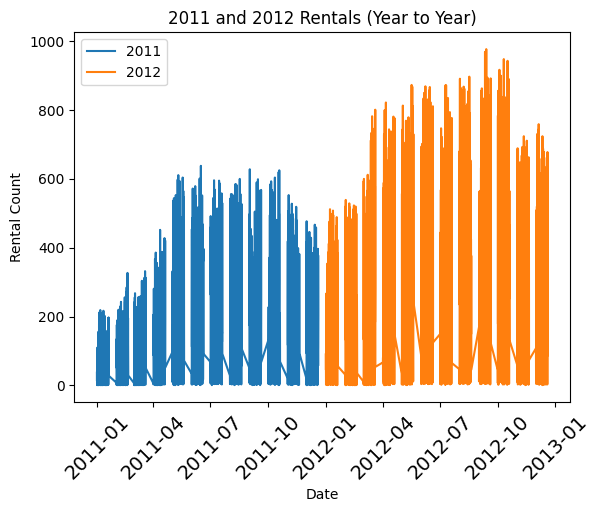

In [8]:
# 过滤出2011年和2012年的数据
df_2011 = df[df['year'] == 2011]
df_2012 = df[df['year'] == 2012]

# 绘制2011年和2012年的count数据
plt.plot(df_2011.index, df_2011['count'], label='2011')
plt.plot(df_2012.index, df_2012['count'], label='2012')

# 设置x轴的标签旋转45度，设置字体大小为14
plt.xticks(fontsize=14, rotation=45)

# 设置图表的标签和标题
plt.xlabel('Date')
plt.ylabel('Rental Count')
plt.title('2011 and 2012 Rentals (Year to Year)')

# 显示图例
plt.legend()

# 显示图表
plt.show()

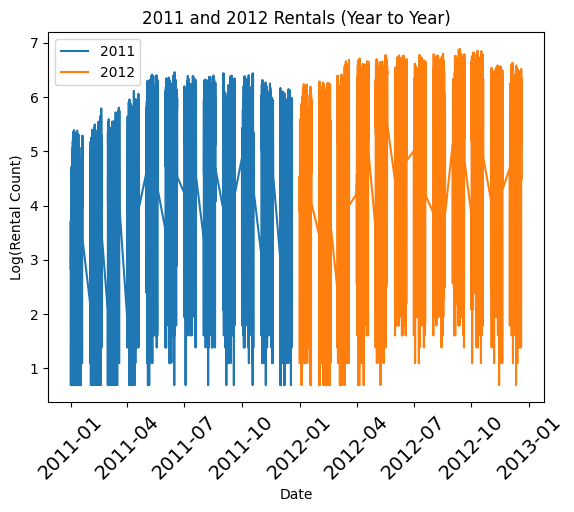

In [9]:
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=pd.errors.SettingWithCopyWarning)
    # 过滤出2011年和2012年的数据
    df_2011 = df[df['year'] == 2011]
    df_2012 = df[df['year'] == 2012]
    
    # 对count列应用np.log1p函数
    df_2011['count_log'] = df_2011['count'].map(np.log1p)
    df_2012['count_log'] = df_2012['count'].map(np.log1p)
    
    # 绘制2011年和2012年的count对数数据
    plt.plot(df_2011.index, df_2011['count_log'], label='2011')
    plt.plot(df_2012.index, df_2012['count_log'], label='2012')
    
    # 设置x轴的标签旋转45度，设置字体大小为14
    plt.xticks(fontsize=14, rotation=45)
    
    # 设置图表的标签和标题
    plt.xlabel('Date')
    plt.ylabel('Log(Rental Count)')
    plt.title('2011 and 2012 Rentals (Year to Year)')
    
    # 显示图例
    plt.legend()
    
    # 显示图表
    plt.show()

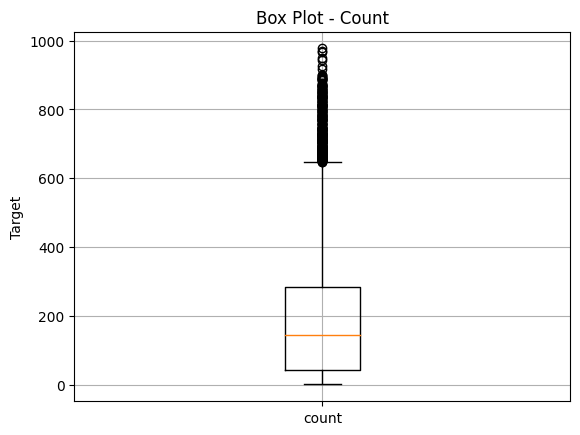

In [10]:
# 观察数据分布的 box plot 图
plt.boxplot([df['count']], labels=['count'])
plt.title('Box Plot - Count')
plt.ylabel('Target')
plt.grid(True)

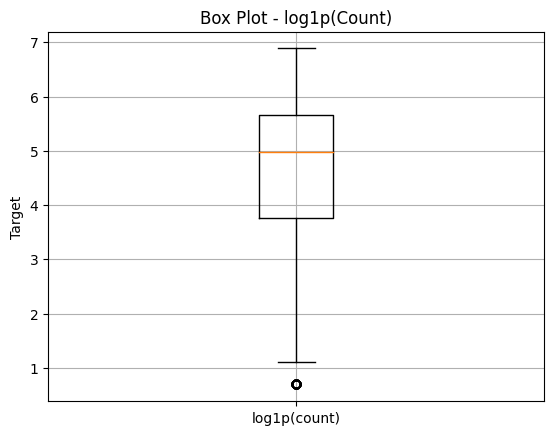

In [11]:
# 观察数据分布如何随着 log1p 变化
# 均匀分布
plt.boxplot([df['count'].map(np.log1p)], labels=['log1p(count)'])
plt.title('Box Plot - log1p(Count)')
plt.ylabel('Target')
plt.grid(True)

In [12]:
df["count"] = df["count"].map(np.log1p)

In [13]:
df.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,dayofweek,hour
datetime,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,2.833213,2011,1,1,5,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,3.713572,2011,1,1,5,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,3.496508,2011,1,1,5,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,2.639057,2011,1,1,5,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,0.693147,2011,1,1,5,4


In [14]:
df_test.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,year,month,day,dayofweek,hour
datetime,,,,,,,,,,,,,
2011-01-20 00:00:00,1,0,1,1,10.66,11.365,56,26.0027,2011,1,20,3,0
2011-01-20 01:00:00,1,0,1,1,10.66,13.635,56,0.0000,2011,1,20,3,1
2011-01-20 02:00:00,1,0,1,1,10.66,13.635,56,0.0000,2011,1,20,3,2
2011-01-20 03:00:00,1,0,1,1,10.66,12.880,56,11.0014,2011,1,20,3,3
2011-01-20 04:00:00,1,0,1,1,10.66,12.880,56,11.0014,2011,1,20,3,4


In [15]:
df.dtypes

season          int64
holiday         int64
workingday      int64
weather         int64
temp          float64
atemp         float64
humidity        int64
windspeed     float64
casual          int64
registered      int64
count         float64
year            int32
month           int32
day             int32
dayofweek       int32
hour            int32
dtype: object

In [16]:
# 保存所有数据
df.to_csv('bike_all.csv',index=True,index_label='datetime',columns=columns)

# 训练和验证集
* 目标变量作为第一列，随后是输入特征
* 训练和验证文件没有列标题

In [17]:
# 训练集 = 数据的70%
# 验证集 = 数据的30%
# 随机化数据集
np.random.seed(5)
l = list(df.index)
np.random.shuffle(l)
df = df.loc[l]

In [18]:
rows = df.shape[0]
train = int(.7 * rows)
test = rows-train

In [19]:
rows, train, test

(10886, 7620, 3266)

In [20]:
columns

['count',
 'season',
 'holiday',
 'workingday',
 'weather',
 'temp',
 'atemp',
 'humidity',
 'windspeed',
 'year',
 'month',
 'day',
 'dayofweek',
 'hour']

In [21]:
# 写入训练集
df.iloc[:train].to_csv('bike_train.csv'
                          ,index=False,header=False
                          ,columns=columns)

In [22]:
# 写入验证集
df.iloc[train:].to_csv('bike_validation.csv'
                          ,index=False,header=False
                          ,columns=columns)

In [23]:
# 测试数据仅包含输入特征
df_test.to_csv('bike_test.csv',index=True,index_label='datetime')

In [24]:
print(','.join(columns))

count,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,year,month,day,dayofweek,hour


In [25]:
# 写入列列表
with open('bike_train_column_list.txt','w') as f:
    f.write(','.join(columns))

# 使用SKLearn的神经网络（NN）进行回归
* 对分类特征进行独热编码，对数值特征进行标准化
* 目标：

* 训练一个自行车租赁预测模型
* NN需要对分类数据进行独热编码
* NN还要求特征具有相似的比例尺
* 对所有分类特征进行独热编码：['season', 'holiday', 'workingday', 'weather', 'year', 'month', 'day', 'dayofweek', 'hour']
* 验证模型性能

In [26]:
import sys
import numpy as np
# 设置随机种子
np.random.seed(0)

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# NN
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler, KBinsDiscretizer
# Column Transformer
from sklearn.compose import ColumnTransformer

In [27]:
column_list_file = 'bike_train_column_list.txt'
train_file = 'bike_train.csv'
validation_file = 'bike_validation.csv'
test_file = 'bike_test.csv'

# 独热编码

In [28]:
# 对所有分类特征进行独热编码
# 让我们定义所有的分类特征
categorical_features = ['season','holiday','workingday','weather','year','month','dayofweek','hour']

# 标准化特征
standardize_features = ['temp', 'atemp', 'humidity', 'windspeed']

In [29]:
columns = ''
with open(column_list_file,'r') as f:
    columns = f.read().split(',')

In [30]:
columns

['count',
 'season',
 'holiday',
 'workingday',
 'weather',
 'temp',
 'atemp',
 'humidity',
 'windspeed',
 'year',
 'month',
 'day',
 'dayofweek',
 'hour']

In [31]:
# 指定列名为文件没有列标题
df_train = pd.read_csv(train_file,names=columns)
df_validation = pd.read_csv(validation_file,names=columns)

In [32]:
df_train.head()

,count,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,year,month,day,dayofweek,hour
0,4.477337,3,0,0,2,26.24,30.305,73,7.0015,2011,9,3,5,0
1,5.517453,3,0,1,1,32.80,34.850,33,7.0015,2012,8,13,0,14
2,5.814131,4,0,0,1,15.58,19.695,40,11.0014,2011,11,5,5,17
3,6.436150,3,0,1,1,32.80,37.880,55,12.9980,2012,8,9,3,19
4,4.262680,2,0,1,1,13.94,17.425,76,7.0015,2011,4,14,3,6


In [33]:
df_validation.head()

,count,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,year,month,day,dayofweek,hour
0,6.095825,3,0,1,2,28.70,33.335,79,12.9980,2011,7,7,3,8
1,5.961005,2,0,0,1,32.80,37.880,55,12.9980,2011,6,11,5,13
2,1.098612,1,0,1,1,14.76,16.665,40,19.9995,2011,2,14,0,2
3,3.891820,1,0,1,1,9.02,9.090,47,36.9974,2011,2,8,1,10
4,4.025352,4,0,0,1,10.66,15.150,87,0.0000,2011,12,4,6,8


In [34]:
X_train = df_train.iloc[:,1:] # 特征：从第1列开始
y_train = df_train.iloc[:,0].to_numpy() # 目标：第0列

X_validation = df_validation.iloc[:,1:]
y_validation = df_validation.iloc[:,0].to_numpy()

In [35]:
df_train.head()

,count,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,year,month,day,dayofweek,hour
0,4.477337,3,0,0,2,26.24,30.305,73,7.0015,2011,9,3,5,0
1,5.517453,3,0,1,1,32.80,34.850,33,7.0015,2012,8,13,0,14
2,5.814131,4,0,0,1,15.58,19.695,40,11.0014,2011,11,5,5,17
3,6.436150,3,0,1,1,32.80,37.880,55,12.9980,2012,8,9,3,19
4,4.262680,2,0,1,1,13.94,17.425,76,7.0015,2011,4,14,3,6


In [36]:
# 需要进行独热编码的特征
categorical_features+['day']

['season',
 'holiday',
 'workingday',
 'weather',
 'year',
 'month',
 'dayofweek',
 'hour',
 'day']

In [37]:
# 需要进行标准化的特征
standardize_features

['temp', 'atemp', 'humidity', 'windspeed']

# 列变换器/新思路
* 串联所有数据转换
* 简单直接

In [38]:
colTransformer = ColumnTransformer([('onehot',
                                     OneHotEncoder(categories='auto',sparse_output=False),
                                     categorical_features),
                                    ('onehotday',
                                     OneHotEncoder(categories=[[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]],
                                                   sparse_output=False),
                                     ['day']),
                                    ('standardize',
                                    StandardScaler(),standardize_features)
                                   ],
                                   remainder="passthrough")

In [39]:
colTransformer.fit(X_train)

ColumnTransformer(remainder='passthrough',
                  transformers=[('onehot', OneHotEncoder(sparse_output=False),
                                 ['season', 'holiday', 'workingday', 'weather',
                                  'year', 'month', 'dayofweek', 'hour']),
                                ('onehotday',
                                 OneHotEncoder(categories=[[1, 2, 3, 4, 5, 6, 7,
                                                            8, 9, 10, 11, 12,
                                                            13, 14, 15, 16, 17,
                                                            18, 19, 20, 21, 22,
                                                            23, 24, 25, 26, 27,
                                                            28, 29, 30, ...]],
                                               sparse_output=False),
                                 ['day']),
                                ('standardize', StandardScaler(),
                                 ['temp', 'atemp', 'humidity', 'windspeed'])])

In [40]:
X_train_encoded = colTransformer.transform(X_train)
X_validation_encoded = colTransformer.transform(X_validation)

In [41]:
print('Training Data',X_train.shape, 'OneHot Encoded',X_train_encoded.shape)
print('Val Data',X_validation.shape, 'OneHot Encoded',X_validation_encoded.shape)

Training Data (7620, 13) OneHot Encoded (7620, 92)
Val Data (3266, 13) OneHot Encoded (3266, 92)


In [42]:
X_train_encoded[:1]

array([[ 0.        ,  0.        ,  1.        ,  0.        ,  1.        ,
         0.        ,  1.        ,  0.        ,  0.        ,  1.        ,
         0.        ,  0.        ,  1.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  1.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  1.        ,  0.        ,  1.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  1.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0. 

In [43]:
X_validation_encoded[:1]

array([[0.        , 0.        , 1.        , 0.        , 1.        ,
        0.        , 0.        , 1.        , 0.        , 1.        ,
        0.        , 0.        , 1.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        1.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 1.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 1.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 1.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.  

# 训练一个神经网络回归器

In [44]:
nn_regressor = MLPRegressor(random_state=5, 
                            hidden_layer_sizes=[100],
                            activation='relu',
                            max_iter=100)

In [45]:
nn_regressor

MLPRegressor(hidden_layer_sizes=[100], max_iter=100, random_state=5)

In [46]:
%%time
nn_regressor.fit(X_train_encoded,y_train)

CPU times: user 16.4 s, sys: 12.1 s, total: 28.5 s
Wall time: 7.44 s


/opt/conda/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPRegressor(hidden_layer_sizes=[100], max_iter=100, random_state=5)

In [47]:
# 使用模型之前未见过的数据集比较实际与预测的性能
df = pd.read_csv(validation_file,names=columns)

In [48]:
df.head()

,count,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,year,month,day,dayofweek,hour
0,6.095825,3,0,1,2,28.70,33.335,79,12.9980,2011,7,7,3,8
1,5.961005,2,0,0,1,32.80,37.880,55,12.9980,2011,6,11,5,13
2,1.098612,1,0,1,1,14.76,16.665,40,19.9995,2011,2,14,0,2
3,3.891820,1,0,1,1,9.02,9.090,47,36.9974,2011,2,8,1,10
4,4.025352,4,0,0,1,10.66,15.150,87,0.0000,2011,12,4,6,8


In [49]:
result = nn_regressor.predict(X_validation_encoded)

In [50]:
result[:5]

array([6.15758232, 5.93196715, 1.27710594, 3.91617107, 3.77289797])

In [51]:
df['count_predicted'] = result

In [52]:
df.head()

,count,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,year,month,day,dayofweek,hour,count_predicted
0,6.095825,3,0,1,2,28.70,33.335,79,12.9980,2011,7,7,3,8,6.157582
1,5.961005,2,0,0,1,32.80,37.880,55,12.9980,2011,6,11,5,13,5.931967
2,1.098612,1,0,1,1,14.76,16.665,40,19.9995,2011,2,14,0,2,1.277106
3,3.891820,1,0,1,1,9.02,9.090,47,36.9974,2011,2,8,1,10,3.916171
4,4.025352,4,0,0,1,10.66,15.150,87,0.0000,2011,12,4,6,8,3.772898


In [53]:
df['count_predicted'].describe()

count    3266.000000
mean        4.560944
std         1.394138
min         0.386789
25%         3.763872
50%         4.945768
75%         5.605207
max         6.879171
Name: count_predicted, dtype: float64

In [54]:
# 将 log(count) 转换回 count
df['count'] = df['count'].map(np.expm1)
df['count_predicted'] = df['count_predicted'].map(np.expm1)

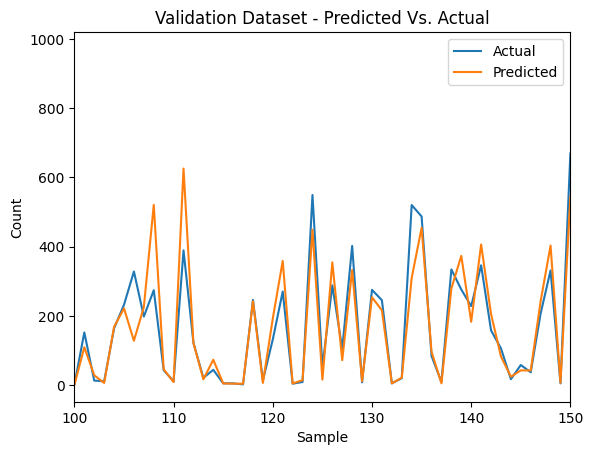

In [55]:
# Actual Vs Predicted
plt.plot(df['count'], label='Actual')
plt.plot(df['count_predicted'],label='Predicted')
plt.xlabel('Sample')
plt.ylabel('Count')
plt.xlim([100,150])
plt.title('Validation Dataset - Predicted Vs. Actual')
plt.legend()
plt.show()

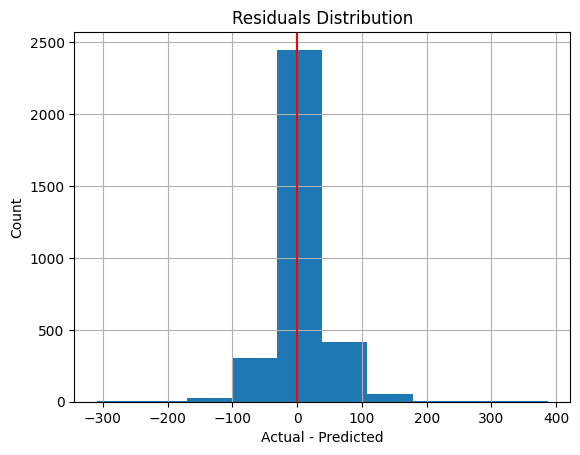

In [56]:
# 需要平衡过预测和欠预测
# 训练数据残差
residuals = (df['count'] - df['count_predicted'])

plt.hist(residuals)
plt.grid(True)
plt.xlabel('Actual - Predicted')
plt.ylabel('Count')
plt.title('Residuals Distribution')
plt.axvline(color='r')
plt.show()

In [57]:
value_counts = (residuals > 0).value_counts(sort=False)
print(' Under Estimation: {0:.2f}'.format(value_counts[True]/len(residuals)))
print(' Over  Estimation: {0:.2f}'.format(value_counts[False]/len(residuals)))

 Under Estimation: 0.59
 Over  Estimation: 0.41


In [58]:
import sklearn.metrics as metrics
print("RMSE: {0:.2f}".format(metrics.mean_squared_error(df['count'],
                                                    df['count_predicted'])**.5))

RMSE: 43.48


In [59]:
# Metric Use By Kaggle
def compute_rmsle(y_true, y_pred):
    if type(y_true) != np.ndarray:
        y_true = np.array(y_true)
        
    if type(y_pred) != np.ndarray:
        y_pred = np.array(y_pred)
     
    return(np.average((np.log1p(y_pred) - np.log1p(y_true))**2)**.5)

In [60]:
print("RMSLE: {0:.2f}".format(compute_rmsle(df['count'],df['count_predicted'])))

RMSLE: 0.29


# 最终成果

In [61]:
# 可选的测试数据
df_test = pd.read_csv(test_file,parse_dates=['datetime'])

In [62]:
X_test =  df_test.iloc[:,1:] # 预测时排除datetime

In [63]:
X_test.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,year,month,day,dayofweek,hour
0,1,0,1,1,10.66,11.365,56,26.0027,2011,1,20,3,0
1,1,0,1,1,10.66,13.635,56,0.0000,2011,1,20,3,1
2,1,0,1,1,10.66,13.635,56,0.0000,2011,1,20,3,2
3,1,0,1,1,10.66,12.880,56,11.0014,2011,1,20,3,3
4,1,0,1,1,10.66,12.880,56,11.0014,2011,1,20,3,4


In [64]:
# 首先使用列变换器转换数据
result = nn_regressor.predict(colTransformer.transform(X_test))

In [65]:
# 将结果转换为实际计数
df_test["count"] = np.expm1(result)

In [66]:
df_test.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,year,month,day,dayofweek,hour,count
0,2011-01-20 00:00:00,1,0,1,1,10.66,11.365,56,26.0027,2011,1,20,3,0,4.562644
1,2011-01-20 01:00:00,1,0,1,1,10.66,13.635,56,0.0000,2011,1,20,3,1,2.719617
2,2011-01-20 02:00:00,1,0,1,1,10.66,13.635,56,0.0000,2011,1,20,3,2,1.433917
3,2011-01-20 03:00:00,1,0,1,1,10.66,12.880,56,11.0014,2011,1,20,3,3,0.653550
4,2011-01-20 04:00:00,1,0,1,1,10.66,12.880,56,11.0014,2011,1,20,3,4,0.615454


In [67]:
df_test[df_test["count"] < 0]

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,year,month,day,dayofweek,hour,count
27,2011-01-21 03:00:00,1,0,1,3,9.02,10.605,80,19.9995,2011,1,21,4,3,-0.033572
75,2011-01-23 05:00:00,1,0,0,2,1.64,3.790,57,7.0015,2011,1,23,6,5,-0.003548
76,2011-01-23 06:00:00,1,0,0,2,1.64,3.790,57,7.0015,2011,1,23,6,6,-0.004581


In [68]:
df_test[['datetime','count']].to_csv('Method_1_Predicted_Count.csv',index=False)

# 构建Keras模型进行回归
使用Keras构建神经网络 - 易于在不同实现之间移植

* 训练一个自行车租赁预测模型
* 神经网络需要对分类数据进行独热编码
* 神经网络还要求特征具有相似的比例尺
* 对所有分类特征进行独热编码：['season', 'holiday', 'workingday', 'weather', 'year', 'month', 'day', 'dayofweek', 'hour']
* 验证模型性能

In [69]:
import sys
import numpy as np
# 设置随机种子
np.random.seed(0)

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Column Transformer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler, KBinsDiscretizer

# Keras Library
from keras.models import Sequential
from keras.layers import Dense, Activation

In [70]:
column_list_file = 'bike_train_column_list.txt'
train_file = 'bike_train.csv'
validation_file = 'bike_validation.csv'
test_file = 'bike_test.csv'

In [71]:
# 对所有分类特征进行独热编码
# 让我们定义所有的分类特征
categorical_features = ['season','holiday','workingday','weather','year','month','dayofweek','hour']

categorical_day = ['day']

# 需要标准化的特征
standardize_features = ['temp', 'atemp', 'humidity', 'windspeed']

In [72]:
columns = ''
with open(column_list_file,'r') as f:
    columns = f.read().split(',')

In [73]:
# 指定列名，因为文件没有列标题
df_train = pd.read_csv(train_file,names=columns)
df_validation = pd.read_csv(validation_file,names=columns)

In [74]:
df_train.head()

,count,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,year,month,day,dayofweek,hour
0,4.477337,3,0,0,2,26.24,30.305,73,7.0015,2011,9,3,5,0
1,5.517453,3,0,1,1,32.80,34.850,33,7.0015,2012,8,13,0,14
2,5.814131,4,0,0,1,15.58,19.695,40,11.0014,2011,11,5,5,17
3,6.436150,3,0,1,1,32.80,37.880,55,12.9980,2012,8,9,3,19
4,4.262680,2,0,1,1,13.94,17.425,76,7.0015,2011,4,14,3,6


In [75]:
df_validation.head()

,count,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,year,month,day,dayofweek,hour
0,6.095825,3,0,1,2,28.70,33.335,79,12.9980,2011,7,7,3,8
1,5.961005,2,0,0,1,32.80,37.880,55,12.9980,2011,6,11,5,13
2,1.098612,1,0,1,1,14.76,16.665,40,19.9995,2011,2,14,0,2
3,3.891820,1,0,1,1,9.02,9.090,47,36.9974,2011,2,8,1,10
4,4.025352,4,0,0,1,10.66,15.150,87,0.0000,2011,12,4,6,8


In [76]:
X_train = df_train.iloc[:,1:] # Features: 1st column onwards 
y_train = df_train.iloc[:,0].to_numpy() # Target: 0th column

X_validation = df_validation.iloc[:,1:]
y_validation = df_validation.iloc[:,0].to_numpy()

In [77]:
colTransformer = ColumnTransformer([('onehot',
                                     OneHotEncoder(categories='auto',sparse_output=False),
                                     categorical_features),
                                    ('onehotday',
                                     OneHotEncoder(categories=[[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]],
                                                   sparse_output=False),
                                     ['day']),
                                    ('standardize',
                                    StandardScaler(),standardize_features)
                                   ],
                                   remainder="passthrough")

In [78]:
colTransformer.fit(X_train)

ColumnTransformer(remainder='passthrough',
                  transformers=[('onehot', OneHotEncoder(sparse_output=False),
                                 ['season', 'holiday', 'workingday', 'weather',
                                  'year', 'month', 'dayofweek', 'hour']),
                                ('onehotday',
                                 OneHotEncoder(categories=[[1, 2, 3, 4, 5, 6, 7,
                                                            8, 9, 10, 11, 12,
                                                            13, 14, 15, 16, 17,
                                                            18, 19, 20, 21, 22,
                                                            23, 24, 25, 26, 27,
                                                            28, 29, 30, ...]],
                                               sparse_output=False),
                                 ['day']),
                                ('standardize', StandardScaler(),
                                 ['temp', 'atemp', 'humidity', 'windspeed'])])

In [79]:
X_train_encoded = colTransformer.transform(X_train)
X_validation_encoded = colTransformer.transform(X_validation)

In [80]:
print('Training Data',X_train.shape, 'OneHot Encoded',X_train_encoded.shape)
print('Val Data',X_validation.shape, 'OneHot Encoded',X_validation_encoded.shape)

Training Data (7620, 13) OneHot Encoded (7620, 92)
Val Data (3266, 13) OneHot Encoded (3266, 92)


In [81]:
X_train_encoded[:1]

array([[ 0.        ,  0.        ,  1.        ,  0.        ,  1.        ,
         0.        ,  1.        ,  0.        ,  0.        ,  1.        ,
         0.        ,  0.        ,  1.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  1.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  1.        ,  0.        ,  1.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  1.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0. 

In [82]:
X_validation_encoded[:1]

array([[0.        , 0.        , 1.        , 0.        , 1.        ,
        0.        , 0.        , 1.        , 0.        , 1.        ,
        0.        , 0.        , 1.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        1.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 1.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 1.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 1.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.  

# 使用Keras构建模型

In [83]:
# 输入数据的维度
# 在配置第一个隐藏层时，我们需要指定特征的数量
X_train_encoded.shape

(7620, 92)

In [84]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=UserWarning)
    model = Sequential()
    # 一个包含100个神经元的隐藏层，使用ReLU激活函数
    # 输出层 - 因为是回归问题，所以没有激活函数
    model.add(Dense(100, input_dim=X_train_encoded.shape[1],activation='relu'))
    model.add(Dense(1,activation=None))

In [85]:
from joblib import dump
dump(nn_regressor, 'mlp_regressor.joblib')

['mlp_regressor.joblib']

In [86]:
# 需要编译模型，指定要使用的优化器和损失函数
# 对于均方误差回归问题
model.compile(optimizer='adam',
              loss='mse')

* 一个避免过拟合的方法使用早停法（Early Stopping Method）。

In [87]:
from keras.callbacks import EarlyStopping

In [88]:
# 我们可以可选地配置早停（Early Stopping）来防止过拟合 - 当验证损失没有改善时停止
early_stopping = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=10)

In [89]:
history = model.fit(X_train_encoded, y_train, epochs=60, batch_size=32, 
          validation_data=(X_validation_encoded,y_validation),callbacks=[early_stopping])

Epoch 1/60
239/239 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 8.0391 - val_loss: 0.5630
Epoch 2/60
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4753 - val_loss: 0.3364
Epoch 3/60
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3150 - val_loss: 0.2760
Epoch 4/60
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2483 - val_loss: 0.2004
Epoch 5/60
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1686 - val_loss: 0.1381
Epoch 6/60
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1173 - val_loss: 0.1188
Epoch 7/60
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1021 - val_loss: 0.1084
Epoch 8/60
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0914 - val_loss: 0.1036
Epoch 9/60
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0858 - val_loss: 0.0968
Epoch 10/60
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0782 - val_loss: 0.0931
Epoch 11/60
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0786 - val_loss: 0.0992
Epoch 12/60
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

In [90]:
model.save('keras_model.h5')

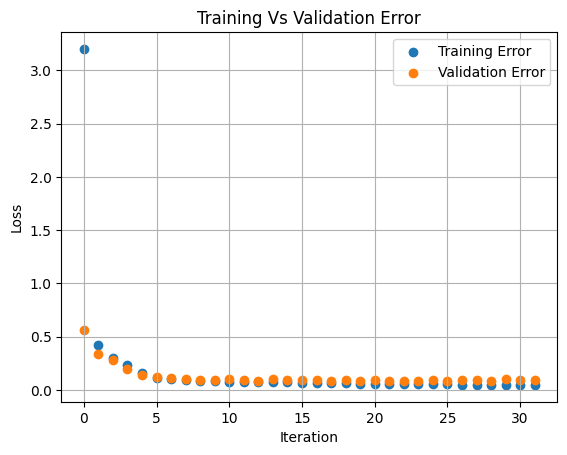

In [91]:
plt.scatter(x=history.epoch,y=history.history['loss'],label='Training Error')
plt.scatter(x=history.epoch,y=history.history['val_loss'],label='Validation Error')
plt.grid(True)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Vs Validation Error')
plt.legend()
plt.show()

In [92]:
# 使用模型之前未见过的数据集比较实际与预测的性能
df = pd.read_csv(validation_file,names=columns)

In [93]:
df.head()

,count,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,year,month,day,dayofweek,hour
0,6.095825,3,0,1,2,28.70,33.335,79,12.9980,2011,7,7,3,8
1,5.961005,2,0,0,1,32.80,37.880,55,12.9980,2011,6,11,5,13
2,1.098612,1,0,1,1,14.76,16.665,40,19.9995,2011,2,14,0,2
3,3.891820,1,0,1,1,9.02,9.090,47,36.9974,2011,2,8,1,10
4,4.025352,4,0,0,1,10.66,15.150,87,0.0000,2011,12,4,6,8


In [94]:
result = model.predict(X_validation_encoded)

103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [95]:
result[:5]

array([[6.2245207],
       [5.8182945],
       [1.1458219],
       [3.6439755],
       [3.931523 ]], dtype=float32)

In [96]:
df.head()

,count,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,year,month,day,dayofweek,hour
0,6.095825,3,0,1,2,28.70,33.335,79,12.9980,2011,7,7,3,8
1,5.961005,2,0,0,1,32.80,37.880,55,12.9980,2011,6,11,5,13
2,1.098612,1,0,1,1,14.76,16.665,40,19.9995,2011,2,14,0,2
3,3.891820,1,0,1,1,9.02,9.090,47,36.9974,2011,2,8,1,10
4,4.025352,4,0,0,1,10.66,15.150,87,0.0000,2011,12,4,6,8


In [97]:
df['count_predicted'] = result

In [98]:
df.head()

,count,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,year,month,day,dayofweek,hour,count_predicted
0,6.095825,3,0,1,2,28.70,33.335,79,12.9980,2011,7,7,3,8,6.224521
1,5.961005,2,0,0,1,32.80,37.880,55,12.9980,2011,6,11,5,13,5.818295
2,1.098612,1,0,1,1,14.76,16.665,40,19.9995,2011,2,14,0,2,1.145822
3,3.891820,1,0,1,1,9.02,9.090,47,36.9974,2011,2,8,1,10,3.643975
4,4.025352,4,0,0,1,10.66,15.150,87,0.0000,2011,12,4,6,8,3.931523


In [99]:
df['count_predicted'].describe()

count    3266.000000
mean        4.534256
std         1.378866
min         0.426666
25%         3.699801
50%         4.923415
75%         5.567512
max         6.849688
Name: count_predicted, dtype: float64

In [100]:
df['count'] = df['count'].map(np.expm1)
df['count_predicted'] = df['count_predicted'].map(np.expm1)

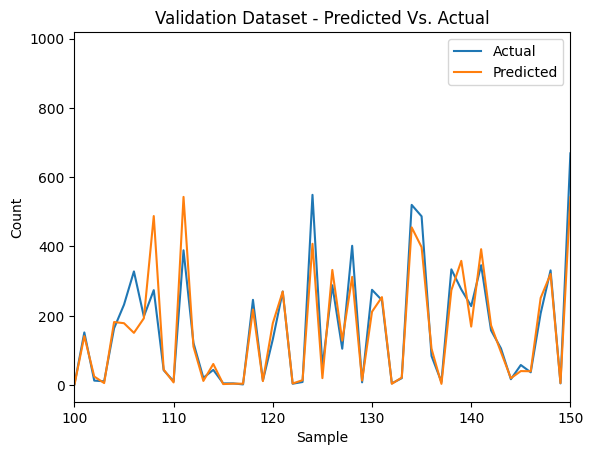

In [101]:
# 实际与预测
plt.plot(df['count'], label='Actual')
plt.plot(df['count_predicted'],label='Predicted')
plt.xlabel('Sample')
plt.ylabel('Count')
plt.xlim([100,150])
plt.title('Validation Dataset - Predicted Vs. Actual')
plt.legend()
plt.show()

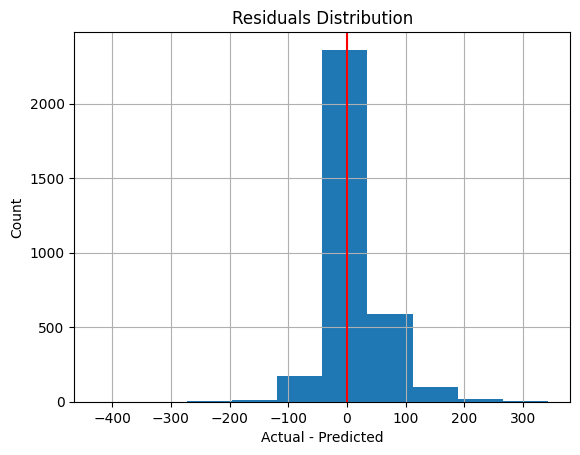

In [102]:
# 需要平衡过预测和欠预测
# 训练数据残差
residuals = (df['count'] - df['count_predicted'])

plt.hist(residuals)
plt.grid(True)
plt.xlabel('Actual - Predicted')
plt.ylabel('Count')
plt.title('Residuals Distribution')
plt.axvline(color='r')
plt.show()

In [103]:
value_counts = (residuals > 0).value_counts(sort=False)
print(' Under Estimation: {0:.2f}'.format(value_counts[True]/len(residuals)))
print(' Over  Estimation: {0:.2f}'.format(value_counts[False]/len(residuals)))

 Under Estimation: 0.65
 Over  Estimation: 0.35


In [104]:
import sklearn.metrics as metrics
print("RMSE: {0:.2f}".format(metrics.mean_squared_error(df['count'],
                                                    df['count_predicted'])**.5))

RMSE: 49.22


In [105]:
# 评估指标
#RMSLE值的大小反映了模型预测准确性的高低，较小的值表示预测值与实际值的相对误差小，模型预测性能好；较大的值则表示相对误差大，模型预测性能差，需要进一步优化。
def compute_rmsle(y_true, y_pred):
    if type(y_true) != np.ndarray:
        y_true = np.array(y_true)
        
    if type(y_pred) != np.ndarray:
        y_pred = np.array(y_pred)
     
    return(np.average((np.log1p(y_pred) - np.log1p(y_true))**2)**.5)

In [106]:
print("RMSLE: {0:.2f}".format(compute_rmsle(df['count'],df['count_predicted'])))

RMSLE: 0.31


# 最终成果

In [107]:
# 可选的测试数据
df_test = pd.read_csv(test_file,parse_dates=['datetime'])

In [108]:
X_test =  df_test.iloc[:,1:] # 预测时排除datetime

In [109]:
# 首先使用列变换器转换数据
result = model.predict(colTransformer.transform(X_test))

203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [110]:
result[:5]

array([[1.8080981 ],
       [1.3921554 ],
       [0.99675715],
       [0.5636373 ],
       [0.6043733 ]], dtype=float32)

In [111]:
# 将结果转换回实际计数
df_test["count"] = np.expm1(result)

In [112]:
df_test.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,year,month,day,dayofweek,hour,count
0,2011-01-20 00:00:00,1,0,1,1,10.66,11.365,56,26.0027,2011,1,20,3,0,5.098837
1,2011-01-20 01:00:00,1,0,1,1,10.66,13.635,56,0.0000,2011,1,20,3,1,3.023513
2,2011-01-20 02:00:00,1,0,1,1,10.66,13.635,56,0.0000,2011,1,20,3,2,1.709481
3,2011-01-20 03:00:00,1,0,1,1,10.66,12.880,56,11.0014,2011,1,20,3,3,0.757052
4,2011-01-20 04:00:00,1,0,1,1,10.66,12.880,56,11.0014,2011,1,20,3,4,0.830105


In [113]:
def adjust_count(x):
    if x < 0:
        return 0
    else:
        return x

In [114]:
df_test[df_test["count"] < 0]

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,year,month,day,dayofweek,hour,count
97,2011-01-24 04:00:00,1,0,1,1,0.82,3.03,48,8.9981,2011,1,24,0,4,-0.000824


In [115]:
df_test['count'] = df_test['count'].map(adjust_count)

In [116]:
df_test[df_test["count"] < 0]

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,year,month,day,dayofweek,hour,count


In [117]:
df_test[['datetime','count']].to_csv('Method_2_Predicted_Count.csv',index=False)

# 实际应用举例

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime
from keras.models import load_model
from keras.losses import MeanSquaredError
from joblib import load
from sklearn.preprocessing import OneHotEncoder
onehot_encoder = OneHotEncoder(handle_unknown='ignore')

# 加载模型和列变换器
def load_models():
    # 加载Keras模型，正确传递custom_objects参数
    keras_model = load_model('/kaggle/working/keras_model.h5', custom_objects={'mse': MeanSquaredError})
    # 加载MLPRegressor模型
    mlp_regressor = load('/kaggle/input/11/keras/default/1/column_transformer.joblib')
    # 加载列变换器
    colTransformer = load('/kaggle/input/11/keras/default/1/mlp_regressor.joblib')
    return keras_model, mlp_regressor, colTransformer

# 预测函数
def predict_bike_sharing(keras_model, mlp_regressor, colTransformer, **features):
    # 创建一个包含输入特征的DataFrame，确保列名和顺序与训练时一致
    columns = ['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'year', 'month', 'day', 'dayofweek', 'hour']
    input_df = pd.DataFrame([features], columns=columns)
    
    # 使用列变换器对输入数据进行相同的预处理
    input_df_encoded = colTransformer.transform(input_df)
    
    # 使用Keras模型进行预测
    keras_prediction = keras_model.predict(input_df_encoded)
    
    # 使用MLPRegressor模型进行预测
    mlp_prediction = mlp_regressor.predict(input_df_encoded)
    
    return keras_prediction[0], mlp_prediction[0]

# 用户输入特征值
def get_user_input():
    # 使用当前年份
    year = 2012
    month = int(input("请输入月份："))
    day = int(input("请输入日期："))
    hour =int(input("请输入时间："))
    temp = float(input("请输入温度："))
    atemp = float(input("请输入体感温度："))
    humidity = float(input("请输入湿度："))
    windspeed = float(input("请输入风速："))
    holiday = int(input("请输入是否假日（0或1）："))
    workingday = int(input("请输入是否工作日（0或1）："))
    weather = int(input("请输入天气状况（1-4）："))

    # 计算季节
    if 3 <= month <= 5:
        season = 1  # 春季
    elif 6 <= month <= 8:
        season = 2  # 夏季
    elif 9 <= month <= 11:
        season = 3  # 秋季
    else:
        season = 4  # 冬季

    # 计算星期几
    date = datetime(year, month, day)
    dayofweek = date.weekday()

    features = {
        'season': season,
        'holiday': holiday,
        'workingday': workingday,
        'weather': weather,
        'temp': temp,
        'atemp': atemp,
        'humidity': humidity,
        'windspeed': windspeed,
        'year': year,
        'month': month,
        'day': day,
        'dayofweek': dayofweek,
        'hour': hour
    }
    return features

def main():
    # 加载模型
    keras_model, mlp_regressor, colTransformer = load_models()
    
    # 获取用户输入
    features = get_user_input()
    
    # 调用预测函数
    keras_predicted_count, mlp_predicted_count = predict_bike_sharing(keras_model, mlp_regressor, colTransformer, **features)
    
    # 将预测的log1p值转换回原始计数
    keras_predicted_count = np.expm1(keras_predicted_count)
    mlp_predicted_count = np.expm1(mlp_predicted_count)
    
    print(f"Keras模型预测的自行车租赁数量为: {keras_predicted_count}")
    print(f"MLPRegressor模型预测的自行车租赁数量为: {mlp_predicted_count}")

# 运行主函数
if __name__ == "__main__":
    main()